Análise de Regressão --- Atividade 1 

Enunciado:
Um pesquisador deseja estudar a relação entre o Consumo (km/l) de um automóvel e a sua
Velocidade Média em um percurso fixo.
1. Gere um conjunto de dados coerente com este problema e apresente o código
utilizado.
2. Ajuste a reta de regressão linear.
3. Apresente os resultados e compare-os com o processo de geração dos dados.
4. Discuta os resultados obtidos.

### 1. Gere um conjunto de dados coerente com este problema e apresente o código utilizado.

Observação: 
Se a gente analisar de forma literal, a unidade km/l se refere à eficiência do automóvel, e a unidade correta para medir o consumo de combustível seria litro por quilômetro (L/km) ou litro por 100 quilômetro (L/100km). 

Eu escolho usar L/100km para a variável Consumo nessa atividade.

um link externo para um url que justifica minha escolha: https://www.terra.com.br/mobilidade/carros/brasileiro-nao-sabe-medir-consumo-do-carro-entenda-o-porque,c114a004c29459e53be9499b53fad9d543q2tx2w.html

O código em R abaixo é usado para gerar os dados

In [1]:
# X: variável regressora; velocidade média do veículo (km/h)
# Y: variável resposta; consumo de combustível (L/100km)
# Gerar X_i's aleatórios 
# 'Calcular' os Y's tais que Y = beta_0 + beta_1*f(X) + um_certo_erro
# Como o automóvel não é especificado (não sei a marca nem modelo)
# vou dizer que f(X) é igual a X,
# e para beta_0 e beta_1 vou encaixar 
# com valores compatíveis com consumo típico entre 5 e 15 L/100km para carros comuns

set.seed(260317)
n <- 100       # número de observações / tamanho da amostra
beta_0 <- 5    # os parâmetros
beta_1 <- 0.015

#gerar uniformemente n números entre 20 a 150
#desconsiderando os dados que estão fora desse intervalo
X <- runif(n, min = 20, max = 150) 

# uns erros aleatórios,homocedásticos
# que seguem uma distribuição normal de media 0 e variancia 0,25
Erros <- rnorm(n, mean = 0, sd = 0.5 ) 

Y <- beta_0 + beta_1 * X + Erros # "Calcular" Y

### 2. Ajuste a reta de regressão linear.


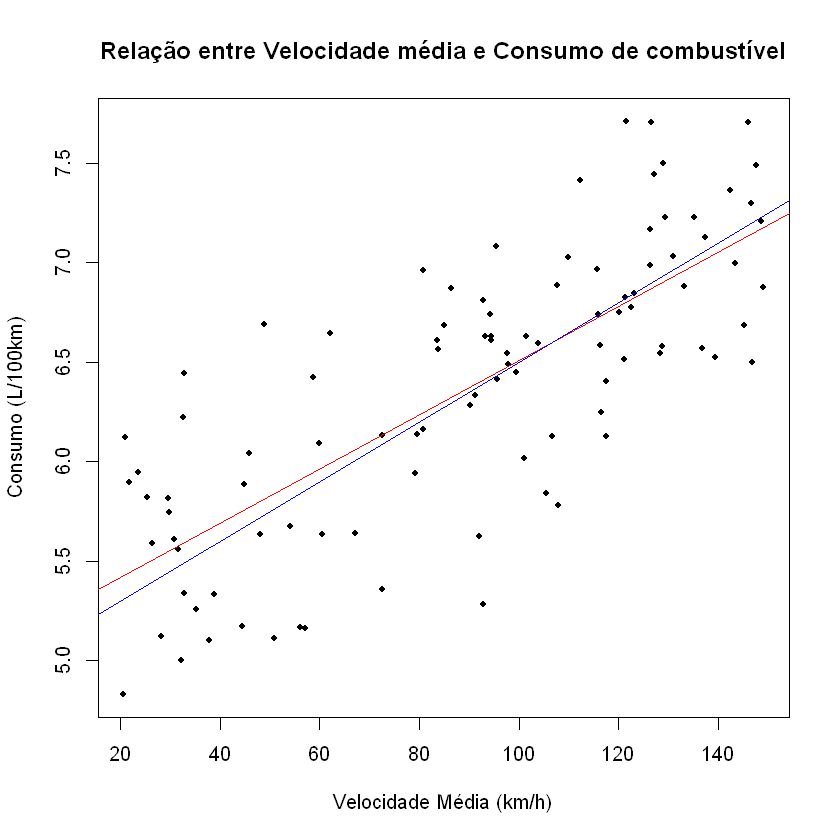

In [107]:
plot(X, Y, # gráfico de dispersão
     main = "Relação entre Velocidade média e Consumo de combustível",
     xlab = "Velocidade Média (km/h)",
     ylab = "Consumo (L/100km)",
     pch = 20
) 

modelo <- lm(Y ~ X) # regressão linear
beta_0_chapeu <- coef(modelo)[1] # coeficientes estimados
beta_1_chapeu <- coef(modelo)[2] 

# adicionar reta (vermelha) de regressão, a partir dos dados gerados
abline(modelo, col = "red") 

# a reta teórica que vem da equação Y = beta_0 + beta_1*X, adicionada para comparar
abline(a = beta_0, b = beta_1, col = "blue") 

Comentários sobre o gráfico: Os dados mostram uma tendência positiva, e a nuvem de dados apresenta uma dispersão uniforme, o que é esperado já que os erros gerados são homocedásticos. Além disso note que a reta de regressão linear e a reta teórica são proxímas, e elas possuem uma diferença pequena devido ao erro aleatório gerado acima no código.

### 3. Apresente os resultados e compare-os com o processo de geração dos dados.


In [117]:
correlacao <- cor(X, Y)
cat("Coeficiente de correlação (X, Y):", round(correlacao, 4), "\n")

comparacao <- data.frame(
  Parametro = c("Intercepto", "Inclinação"),
  Verdadeiro = c(beta_0, beta_1),
  Estimado = c(beta_0_chapeu, beta_1_chapeu),
  
  Erro_absoluto = abs(c(beta_0_chapeu - beta_0,
          beta_1_chapeu - beta_1)),

  Erro_relativo = c(abs(beta_0_chapeu - beta_0)/beta_0,
            abs(beta_1_chapeu - beta_1)/beta_1)
)
comparacao


Coeficiente de correlação (X, Y): 0.7642 


,Parametro,Verdadeiro,Estimado,Erro_absoluto,Erro_relativo
(Intercept),Intercepto,5.000,5.14600266,0.146002661,0.02920053
X,Inclinação,0.015,0.01361642,0.001383579,0.09223862


Foi calculado o coeficiente de correlação entre as variáveis X e Y, o qual apresentou valor positivo (0.7642). Além disso, com os erros relativos são calculados acima, os coeficientes estimados pelo modelo de regressão linear simples (usando a função nativa 'lm' do R) são próximos dos valores utilizados no processo de geração dos dados. Existe uma pequena diferença entre os valores estimados e valores verdadeiros, e isso é esperado para acontecer já que houve uma presença de um erro aleatório.

### 4. Discuta os resultados obtidos.


Pode-se observar que os dados apresentam uma tendência linear crescente, ou seja quando a velocidade média do automóvel aumenta, o seu consumo de combustível tende a aumentar. 

O modelo de regressão linear usado para gerar dados assume que a relação entre as variáveis é (aproximadamente) linear, os erros aleatórios são homocedásticos,

Talvez o modelo não seja o ideal nas situações reais, já que as pessoas pensariam em usar um modelo diferente (por exemplo um modelo parabólico da forma Y = a + bX + cX^2 + erro). Mas, no contexto dessa atividade, acredito o objetivo seja ilustrar o ajuste de um modelo regressão linear simples, o que justificaria a minha escolha.